In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy
from pathlib import Path
import sys

In [53]:
PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT / "src"))

from plotting import set_pubr_theme, pubr_legend


In [ ]:
# Will load csv for each model version as df, combine into one lonf df for evalutaion / plotting

fp = PROJECT_ROOT / "outputs/CNN_outputs" / "64_batch_size_NO_AWEI" / "Outer_fold_metrics_15px_2026-07-21.csv"

outer_cnn_15px_NO_AWEI = pd.read_csv(fp)

outer_cnn_15px_NO_AWEI["AWEIp95"] = False

outer_cnn_15px_NO_AWEI.head()

### CNN outer loop results

First Models ran and didnt save AWEIp95 column to metrics or best_epoch to history, so added here...

In [333]:
# Will load csv for each model version as df, combine into one lonf df for evalutaion / plotting
name_string = "31px_2026-07-23"
folder_string = "31px_patch_NO_AWEI"
AWEI = False

outer_folds_fp = PROJECT_ROOT / "outputs/CNN_outputs" / folder_string / f"Outer_fold_metrics_{name_string}.csv"

outer_metrics = pd.read_csv(outer_folds_fp,
                           index_col = 0
                            )

outer_metrics["AWEIp95"] = AWEI



inner_best_state_fp = PROJECT_ROOT / "outputs/CNN_outputs" / folder_string / f"Inner_fold_best_state_metrics_{name_string}.csv"

inner_best_state = pd.read_csv(inner_best_state_fp,
                                index_col = 0
                                )

inner_best_state["AWEIp95"] = AWEI


history_fp = PROJECT_ROOT / "outputs/CNN_outputs" / folder_string / f"training_run_history_{name_string}.csv"

history = pd.read_csv(history_fp,
                        index_col = 0
                        )


history["AWEIp95"] = AWEI

outer_predictions_fp = PROJECT_ROOT / "outputs/CNN_outputs" / folder_string / f"Outer_fold_predictions_{name_string}.csv"

outer_predictions = pd.read_csv(outer_predictions_fp,  
                                   index_col = 0
                                    )

outer_predictions["AWEIp95"] = AWEI

# I want to save to get the epoch stopped from inner_best_state dataframe and broadcast it onto the histry df using the run_ID to join.
# "many-to-one-merge on run_ID"

history = history.merge(
    inner_best_state[["run_ID", "epoch_stopped"]],
    on = "run_ID",
    how = "left"
)
history["best_epoch"] = history["epoch_stopped"]
history = history.drop(["epoch_stopped"], axis = 1)

outer_metrics.to_csv(outer_folds_fp, index= False)
inner_best_state.to_csv(inner_best_state_fp, index= False)
history.to_csv(history_fp, index= False)
outer_predictions.to_csv(outer_predictions_fp, index= False)


In [334]:
print(history.iloc[1,:])

test_region                      Hartbeespoort
val_region                              Rodman
run_ID             T-Har_V-Rod_31px_2026-07-23
patch_size                                  31
loop                                     inner
epoch                                        2
train_loss                            0.442111
val_loss                               0.60763
val_accuracy                          0.656709
val_f1                                 0.56324
val_precision                           0.7753
val_recall                             0.44227
val_auroc                             0.747438
train_accuracy                        0.798844
train_f1                              0.790905
train_precision                       0.818941
train_recall                          0.764725
train_auroc                           0.876618
AWEIp95                                  False
best_epoch                                19.0
Name: 1, dtype: object


In [175]:
fp = PROJECT_ROOT / "outputs/CNN_outputs" / "64_batch_size_NO_AWEI" / "Inner_fold_best_state_metrics_15px_2026-07-21.csv"

inner_cnn_15px_NO_AWEI = pd.read_csv(fp)

inner_cnn_15px_NO_AWEI["AWEIp95"] = False

inner_cnn_15px_NO_AWEI.head()

,Unnamed: 0,run_ID,patch_size,test_region,val_region,train_loss,val_loss,epoch_stopped,val_accuracy,val_f1,...,train_accuracy,train_f1,train_precision,train_recall,train_auroc,dropout,lr,weight_decay,batch_size,AWEIp95
0,0,T-Har_V-Rod_15px_2026-07-21,15,Hartbeespoort,Rodman,0.131584,0.300662,14,0.902057,0.906015,...,0.953529,0.953467,0.949934,0.957027,0.988241,0.106453,0.003865,0.008539,64,False
1,1,T-Har_V-Mul_15px_2026-07-21,15,Hartbeespoort,Mula,0.143063,0.317465,8,0.871139,0.862015,...,0.950186,0.950591,0.943467,0.957823,0.986619,0.106453,0.003865,0.008539,64,False
2,2,T-Har_V-Inl_15px_2026-07-21,15,Hartbeespoort,Inle,0.103017,0.091133,29,0.972000,0.972056,...,0.963478,0.963505,0.958149,0.968920,0.993081,0.106453,0.003865,0.008539,64,False
3,3,T-Har_V-Vem_15px_2026-07-21,15,Hartbeespoort,Vembanad,0.125342,0.102003,19,0.969530,0.969667,...,0.953435,0.953561,0.946263,0.960972,0.990083,0.106453,0.003865,0.008539,64,False
4,4,T-Har_V-Val_15px_2026-07-21,15,Hartbeespoort,Valsequillo,0.128104,0.145391,17,0.948039,0.947835,...,0.955187,0.955239,0.949525,0.961022,0.989462,0.106453,0.003865,0.008539,64,False


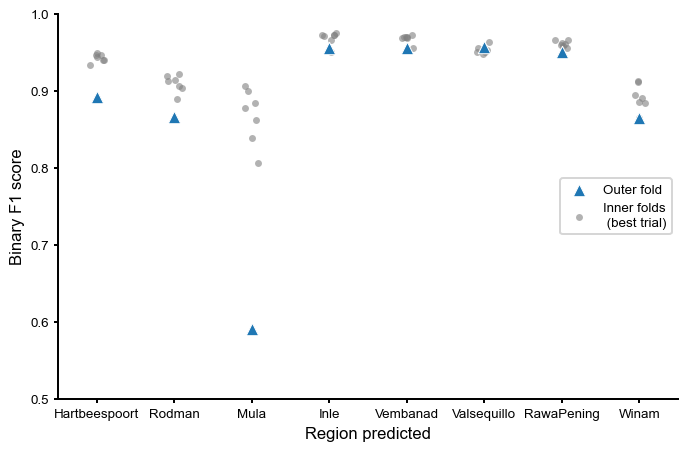

In [297]:
fig, ax = plt.subplots(figsize = (8,5))


set_pubr_theme(legend= "left")

sns.scatterplot(data = outer_cnn_15px_NO_AWEI, ax = ax, x = "test_region", y = "test_f1", label = "Outer fold", marker = "^", s = 80, zorder = 2)
sns.stripplot(data = inner_cnn_15px_NO_AWEI, ax = ax, x = "val_region", y = "val_f1", label = "Inner folds\n (best trial)", alpha = 0.6, color = "gray", zorder = 1)
ax.set_xlabel("Region predicted")
ax.set_ylabel("Binary F1 score")

ax.legend(loc = "lower right")
ax.set_ylim(bottom = 0.5, top = 1)
 
# Deduplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # keeps only the last handle per unique label
ax.legend(by_label.values(), by_label.keys(), loc = "right", frameon = True)



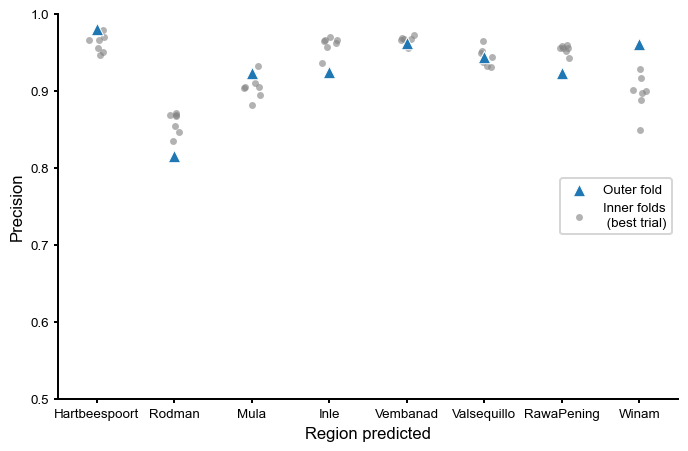

In [299]:
fig, ax = plt.subplots(figsize = (8,5))


set_pubr_theme(legend= "left")

sns.scatterplot(data = outer_cnn_15px_NO_AWEI, ax = ax, x = "test_region", y = "test_precision", label = "Outer fold", marker = "^", s = 80, zorder = 2)
sns.stripplot(data = inner_cnn_15px_NO_AWEI, ax = ax, x = "val_region", y = "val_precision", label = "Inner folds\n (best trial)", alpha = 0.6, color = "gray", zorder = 1)
ax.set_xlabel("Region predicted")
ax.set_ylabel("Precision")

ax.legend(loc = "lower right")
ax.set_ylim(bottom = 0.5, top = 1)
 
# Deduplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # keeps only the last handle per unique label
ax.legend(by_label.values(), by_label.keys(), loc = "right", frameon = True)

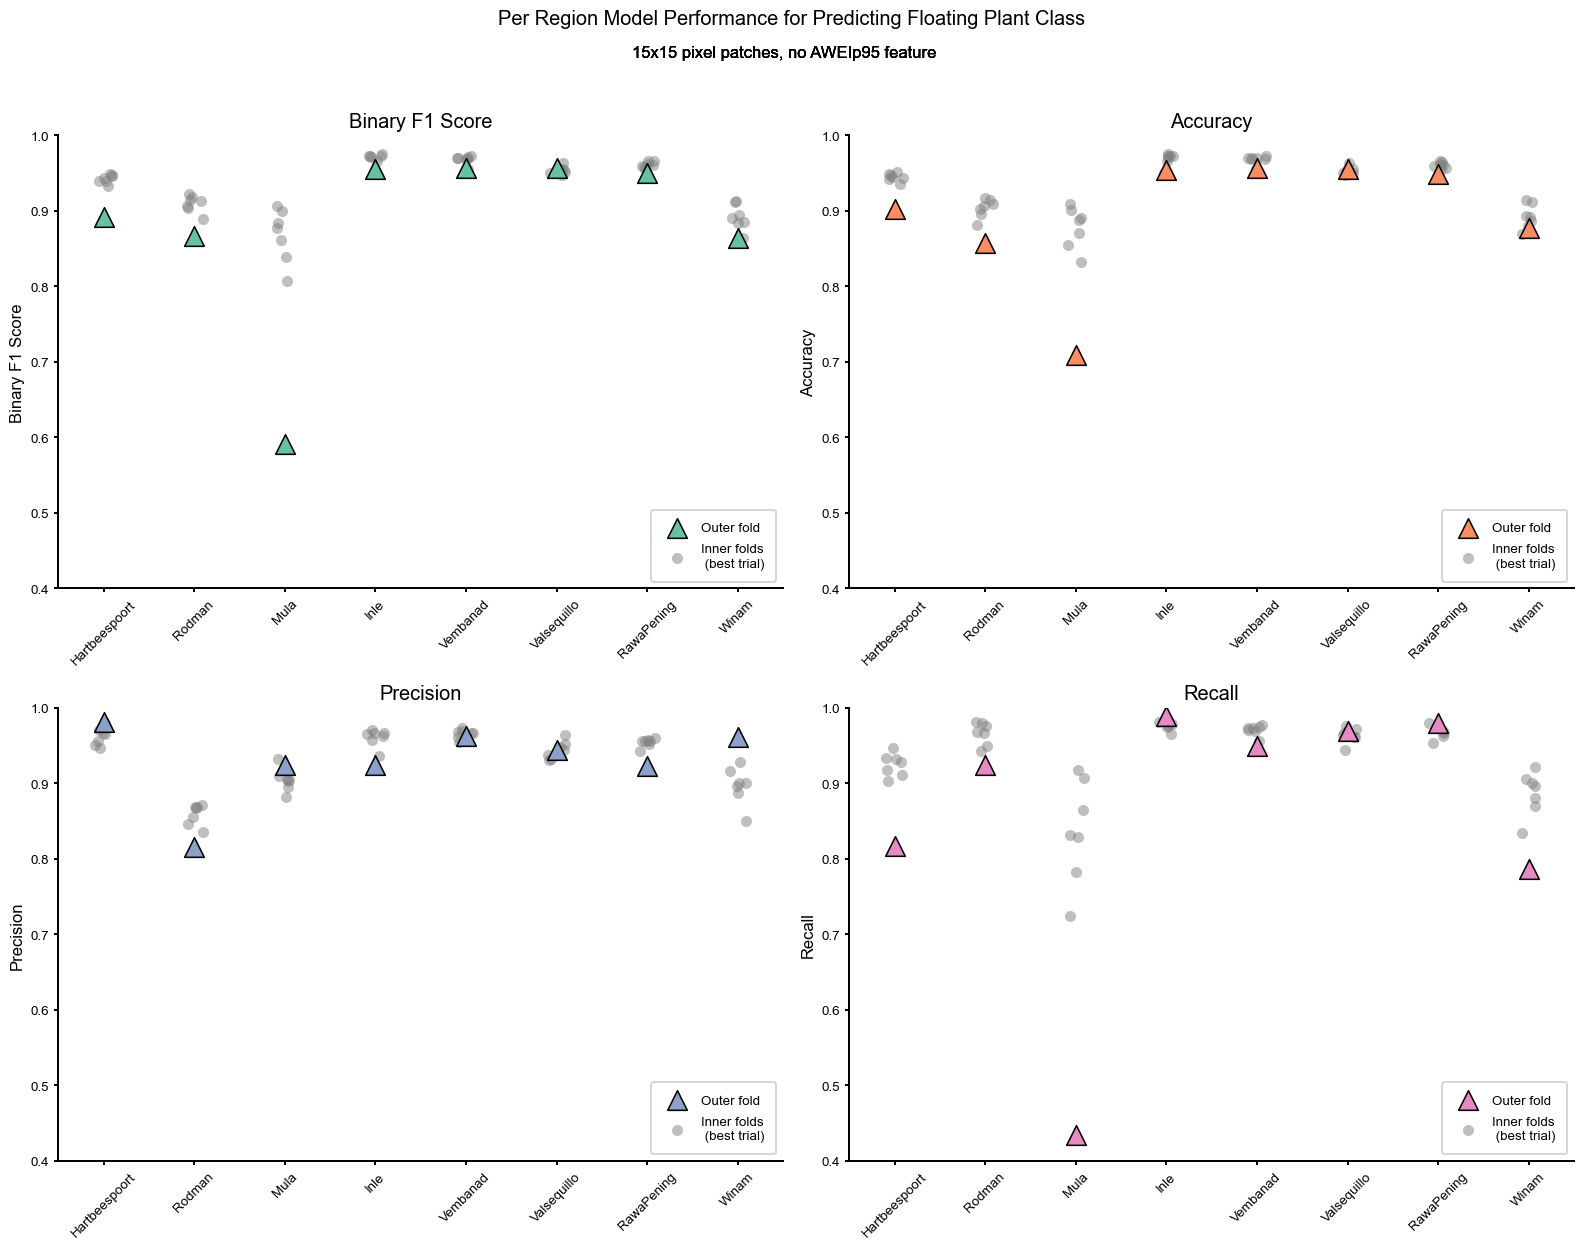

In [300]:

outer_df = outer_cnn_15px_NO_AWEI
inner_df = inner_cnn_15px_NO_AWEI
model = None
text_size = 20

metrics = ["f1", "accuracy","precision","recall"]
metric_name = ["Binary F1 Score", "Accuracy", "Precision", "Recall"]
palette = sns.color_palette("Set2", n_colors = 4)

AWEIp95 = outer_df["AWEIp95"][0]
patch_size = outer_df["patch_size"][0]

set_pubr_theme()
fig, axes = plt.subplots(2,2, figsize = (16, 12))
axes = axes.flatten()

for ax, metric, name, color in zip(axes, metrics, metric_name, palette):
    sns.scatterplot(data = outer_df, ax = ax, x = "test_region", y = f"test_{metric}", color = color, edgecolor = "black", label = "Outer fold", marker = "^", s = 200, zorder = 2)
    sns.stripplot(data = inner_df, ax = ax, x = "val_region", y = f"val_{metric}", label = "Inner folds\n (best trial)", alpha = 0.5, color = "gray",s = 8, zorder = 1)
    ax.set_xlabel("")
    ax.set_ylabel(f"{name}")
    ax.set_title(f"{name}")
    fig.suptitle("Per Region Model Performance for Predicting Floating Plant Class", y = 1.04)
    if AWEIp95:
        if model:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, {model}, with AWEIp95 feature")
        else:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, with AWEIp95 feature")
    else:
        if model:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, {model}, no AWEIp95 feature")
        else:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, no AWEIp95 feature")
    ax.legend(loc = "lower right")
    ax.set_ylim(bottom = 0.4, top = 1)
    ax.tick_params(axis="x", rotation=45)
    
    # Deduplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))  # keeps only the last handle per unique label
    ax.legend(by_label.values(), by_label.keys(), loc = "lower right", frameon = True, borderpad = 0.9, labelspacing = 0.7)
    plt.tight_layout()

### Comparing across models
Per-region model perfomance plotted for different models

In [367]:
# Do this by combining the outer dfs into long so can filter. 

# then can do a group_by(model, patch_size) or just filter
fp1 = PROJECT_ROOT / "outputs/CNN_outputs" / "15px_patch_size_NO_AWEI" / "Outer_fold_metrics_15px_2026-07-21.csv"
fp2 = PROJECT_ROOT / "outputs/CNN_outputs" / "15px_patch_size_WITH_AWEI" / "Outer_fold_metrics_15px_2026-07-22.csv"
fp3 = PROJECT_ROOT / "outputs/CNN_outputs" / "31px_patch_NO_AWEI" / "Outer_fold_metrics_31px_2026-07-23.csv"
# fp4 = PROJECT_ROOT / "outputs/CNN_outputs" / "64_batch_size_NO_AWEI" / "Outer_fold_metrics_15px_2026-07-21.csv"
# fp5 = PROJECT_ROOT / "outputs/CNN_outputs" / "64_batch_size_NO_AWEI" / "Outer_fold_metrics_15px_2026-07-21.csv"
# fp6 = PROJECT_ROOT / "outputs/CNN_outputs" / "64_batch_size_NO_AWEI" / "Outer_fold_metrics_15px_2026-07-21.csv"

outer1 = pd.read_csv(fp1)
outer2 = pd.read_csv(fp2)
outer3 = pd.read_csv(fp3)

combined_outer_folds = pd.concat([outer1, outer2, outer3])
combined_outer_folds["model"] = combined_outer_folds["patch_size"].astype(str) + "_AWEI_" + combined_outer_folds["AWEIp95"].astype(str)

combined_outer_folds

,run_ID,patch_size,test_region,epochs_trained,test_loss,test_accuracy,test_f1,test_precision,test_recall,test_auroc,...,train_f1,train_precision,train_recall,train_auroc,dropout,lr,weight_decay,batch_size,AWEIp95,model
0,Test_Har_outer_15px_2026-07-21,15,Hartbeespoort,17,0.286948,0.902067,0.891671,0.980838,0.817365,0.968925,...,0.952743,0.946014,0.959569,0.988141,0.106453,0.003865,0.008539,64,False,15_AWEI_False
1,Test_Rod_outer_15px_2026-07-21,15,Rodman,10,0.484522,0.857003,0.866055,0.815199,0.923679,0.916700,...,0.963624,0.958738,0.968559,0.993026,0.106453,0.000241,0.000029,64,False,15_AWEI_False
2,Test_Mul_outer_15px_2026-07-21,15,Mula,12,0.642842,0.708977,0.591186,0.923729,0.434696,0.937268,...,0.972797,0.971420,0.974177,0.995720,0.397781,0.001212,0.001176,64,False,15_AWEI_False
3,Test_Inl_outer_15px_2026-07-21,15,Inle,8,0.126887,0.954000,0.955556,0.924299,0.989000,0.994702,...,0.959107,0.955262,0.962984,0.990927,0.162407,0.001575,0.000004,64,False,15_AWEI_False
4,Test_Vem_outer_15px_2026-07-21,15,Vembanad,9,0.128015,0.956543,0.956303,0.962588,0.950100,0.989992,...,0.956669,0.953367,0.959994,0.990258,0.184936,0.004623,0.000005,64,False,15_AWEI_False
5,Test_Val_outer_15px_2026-07-21,15,Valsequillo,15,0.178853,0.955882,0.956480,0.943702,0.969608,0.972875,...,0.952885,0.945152,0.960745,0.988064,0.108234,0.002607,0.007579,64,False,15_AWEI_False
6,Test_Raw_outer_15px_2026-07-21,15,RawaPening,21,0.142661,0.949051,0.950629,0.922932,0.980040,0.987617,...,0.948475,0.937500,0.959711,0.982314,0.323782,0.008362,0.006733,64,False,15_AWEI_False
7,Test_Win_outer_15px_2026-07-21,15,Winam,21,0.412972,0.876938,0.864686,0.960880,0.786000,0.932640,...,0.965220,0.960275,0.970217,0.992570,0.266001,0.009854,0.000782,64,False,15_AWEI_False
0,Test_Har_outer_15px_2026-07-22,15,Hartbeespoort,18,0.301765,0.886811,0.872222,0.983709,0.783433,0.984430,...,0.962303,0.959520,0.965101,0.990905,0.318428,0.006451,0.009583,64,True,15_AWEI_True
1,Test_Rod_outer_15px_2026-07-22,15,Rodman,9,0.177060,0.934868,0.935090,0.932814,0.937378,0.980601,...,0.975475,0.972030,0.978944,0.996169,0.297014,0.000290,0.000005,64,True,15_AWEI_True


Could do, plt with the inner and outer, comparing models, 
Could do plot with each model as a category on the x axid and the y axis is box or violin plot of fold metrics

/var/folders/px/ysdd4tvd6z7255np16x_10l80000gn/T/ipykernel_79747/844753086.py:12: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=combined_outer_folds, x='model', y='test_f1', hue='model', estimator = 'mean',


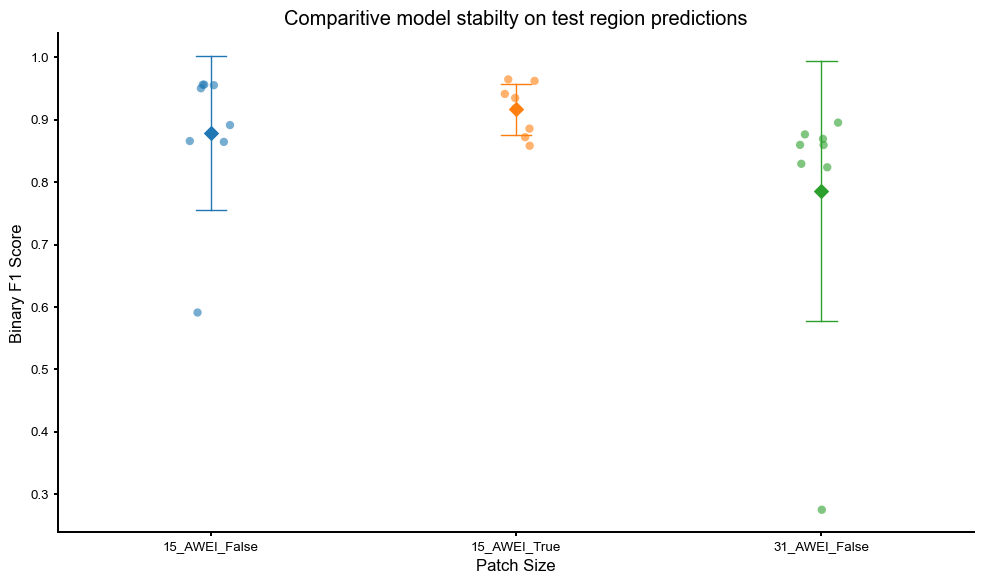

In [375]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# raw points, jittered so they don't overlap
sns.stripplot(data=combined_outer_folds, x='model', y='test_f1', hue='model',
              dodge=False, alpha=0.6, jitter=0.07, size=6, legend=False)

# mean ± SD on top
sns.pointplot(data=combined_outer_folds, x='model', y='test_f1', hue='model', estimator = 'mean',
               join=False, markers='D', linewidth=1, markersize = 7,
              errorbar='sd', capsize=0.1)

plt.xlabel('Patch Size')
plt.title("Comparitive model stabilty on test region predictions")
plt.ylabel('Binary F1 Score')
plt.tight_layout()
plt.show()

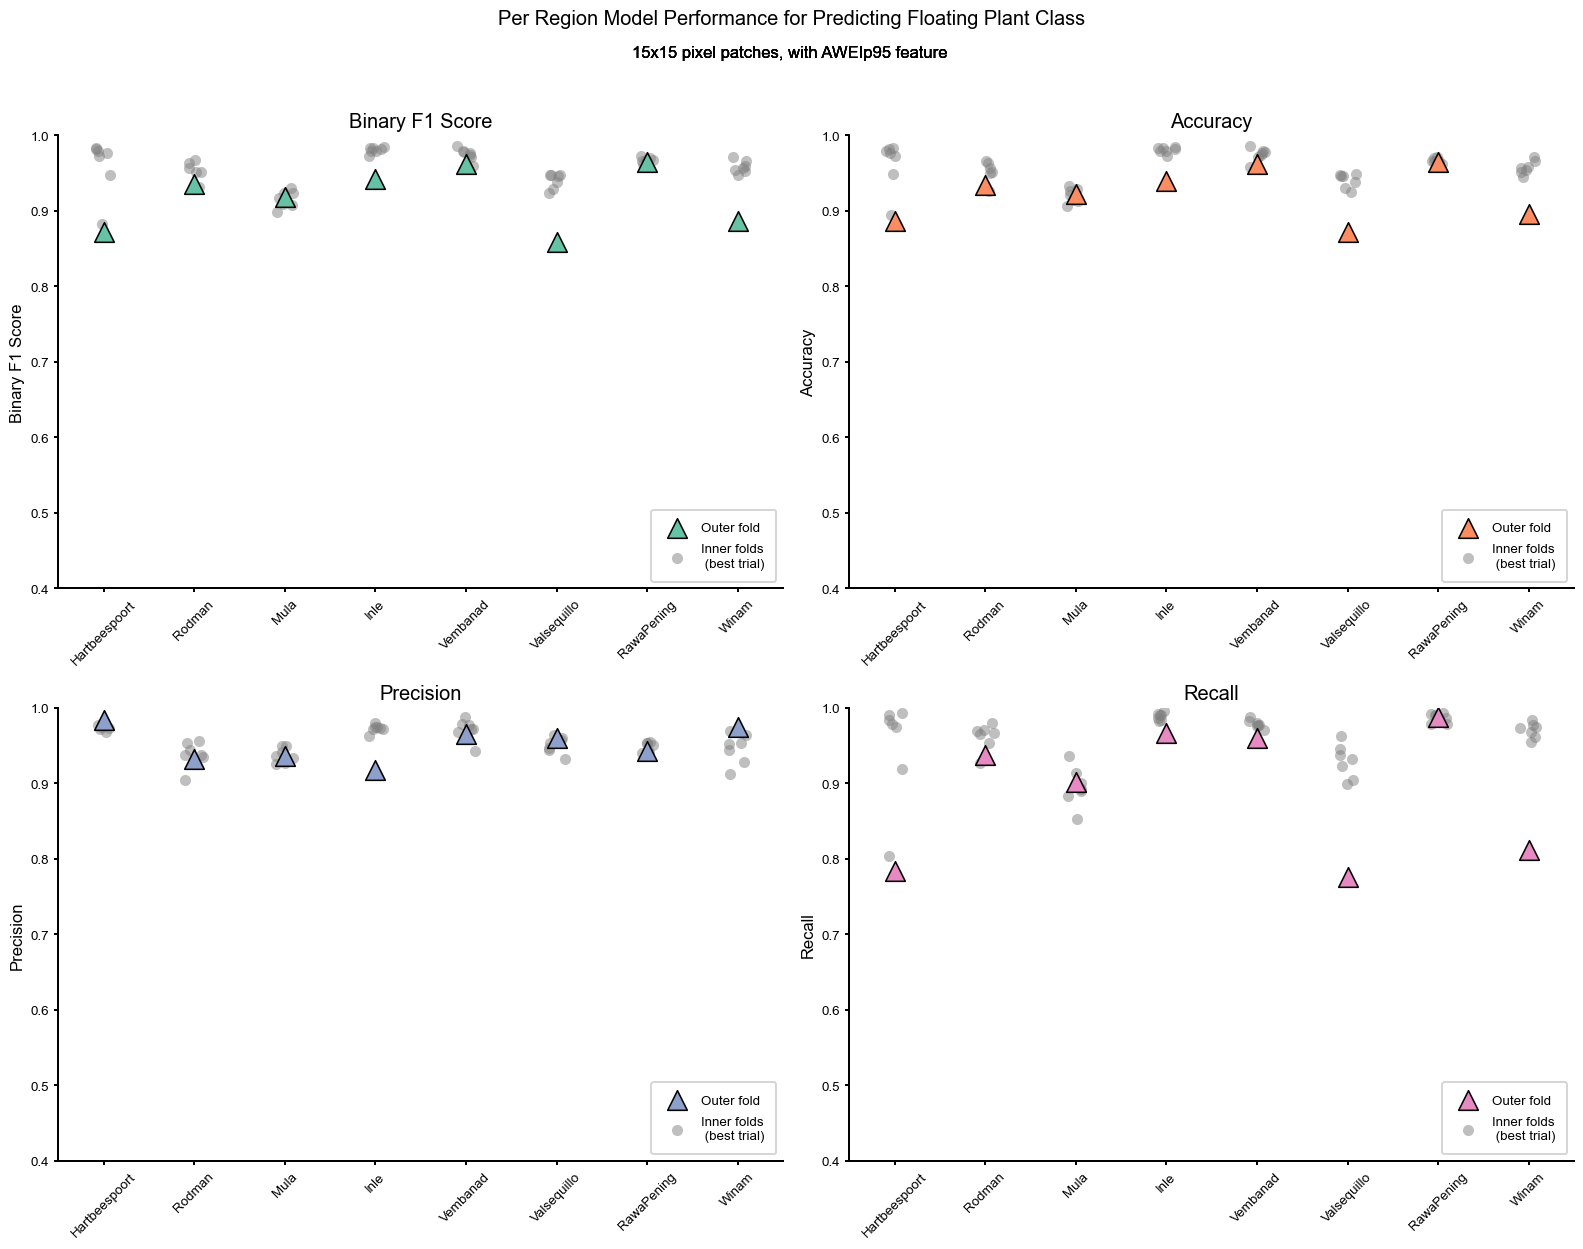

In [376]:
outer_fp = PROJECT_ROOT / "outputs/CNN_outputs" / "15px_patch_size_WITH_AWEI" / "Outer_fold_metrics_15px_2026-07-22.csv"
inner_fp = PROJECT_ROOT / "outputs/CNN_outputs" / "15px_patch_size_WITH_AWEI" / "Inner_fold_best_state_metrics_15px_2026-07-22.csv"

outer_df = pd.read_csv(outer_fp)
inner_df = pd.read_csv(inner_fp)
model = None
text_size = 20

metrics = ["f1", "accuracy","precision","recall"]
metric_name = ["Binary F1 Score", "Accuracy", "Precision", "Recall"]
palette = sns.color_palette("Set2", n_colors = 4)

AWEIp95 = outer_df["AWEIp95"][0]
patch_size = outer_df["patch_size"][0]

set_pubr_theme()
fig, axes = plt.subplots(2,2, figsize = (16, 12))
axes = axes.flatten()

for ax, metric, name, color in zip(axes, metrics, metric_name, palette):
    sns.scatterplot(data = outer_df, ax = ax, x = "test_region", y = f"test_{metric}", color = color, edgecolor = "black", label = "Outer fold", marker = "^", s = 200, zorder = 2)
    sns.stripplot(data = inner_df, ax = ax, x = "val_region", y = f"val_{metric}", label = "Inner folds\n (best trial)", alpha = 0.5, color = "gray",s = 8, zorder = 1)
    ax.set_xlabel("")
    ax.set_ylabel(f"{name}")
    ax.set_title(f"{name}")
    fig.suptitle("Per Region Model Performance for Predicting Floating Plant Class", y = 1.04)
    if AWEIp95:
        if model:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, {model}, with AWEIp95 feature")
        else:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, with AWEIp95 feature")
    else:
        if model:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, {model}, no AWEIp95 feature")
        else:
            fig.text(0.4, 1.0, f"{patch_size}x{patch_size} pixel patches, no AWEIp95 feature")
    ax.legend(loc = "lower right")
    ax.set_ylim(bottom = 0.4, top = 1)
    ax.tick_params(axis="x", rotation=45)
    
    # Deduplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))  # keeps only the last handle per unique label
    ax.legend(by_label.values(), by_label.keys(), loc = "lower right", frameon = True, borderpad = 0.9, labelspacing = 0.7)
    plt.tight_layout()

### Loss curves

In [ ]:
# Want to be able to save some individually then combine others into a facet plot

# Facets would have inner and outer fold for a given test region. 

# History dict is the sdata source

fp = PROJECT_ROOT / "outputs/CNN_outputs" / "64_batch_size_NO_AWEI" / "training_run_history_15px_2026-07-21.csv"

history_cnn_15px_NO_AWEI = pd.read_csv(fp)

history_cnn_15px_NO_AWEI["AWEIp95"] = False


# I want to save to get the epoch stopped from inner_best_state dataframe and broadcast it onto the histry df using the run_ID to join.
# "many-to-one-merge on run_ID"

history_cnn_15px_NO_AWEI = history_cnn_15px_NO_AWEI.merge(
    inner_cnn_15px_NO_AWEI[["run_ID", "epoch_stopped"]],
    on = "run_ID",
    how = "left"
)

print(len(history_cnn_15px_NO_AWEI["run_ID"].unique()))
history_cnn_15px_NO_AWEI.head()

64


,Unnamed: 0,test_region,val_region,run_ID,patch_size,loop,epoch,train_loss,val_loss,val_accuracy,...,val_precision,val_recall,val_auroc,train_accuracy,train_f1,train_precision,train_recall,train_auroc,AWEIp95,epoch_stopped
0,0,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-21,15,inner,1,0.341667,0.933920,0.672380,...,0.607425,0.976517,0.804035,0.854313,0.851418,0.864149,0.839058,0.929194,False,14.0
1,1,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-21,15,inner,2,0.251553,0.426867,0.833007,...,0.852850,0.805284,0.891305,0.905737,0.905102,0.906609,0.903600,0.961864,False,14.0
2,2,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-21,15,inner,3,0.221368,0.527314,0.749265,...,0.840909,0.615460,0.849989,0.920182,0.919851,0.919013,0.920690,0.969599,False,14.0
3,3,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-21,15,inner,4,0.195738,0.697393,0.738981,...,0.887480,0.547945,0.856810,0.930417,0.930094,0.929708,0.930480,0.975728,False,14.0
4,4,Hartbeespoort,Rodman,T-Har_V-Rod_15px_2026-07-21,15,inner,5,0.190710,0.352392,0.887855,...,0.836873,0.963796,0.956258,0.933141,0.932969,0.930659,0.935291,0.976510,False,14.0


In [330]:
def plot_loss_curves(df, test_region, val_region=None, fold="inner", facet=False, ax=None, model = None):
    """Plot training/validation loss curves from the concatenated history_dict dataframe.

    Three modes:
      - facet=True                : grid of train + val loss for every inner
                                    val_region of test_region
      - facet=False, fold="outer" : single train-loss curve for the outer fold
      - facet=False, fold="inner" : single train + val curve for
                                    test_region / val_region

    In the single-plot modes an existing ``ax`` may be passed to draw onto
    (e.g. for side-by-side figures); if omitted the function creates and
    shows its own figure. The axis (or flattened axes array in facet mode)
    is returned. ``ax`` is ignored when facet=True.
    """
    AWEIp95 = df["AWEIp95"][0]
    patch_size = df["patch_size"][0]

    test_regions = df["test_region"].unique()

    if AWEIp95:
        if model:
            subtitle_text = f"{patch_size}x{patch_size} pixel patches, {model}, with AWEIp95 feature"
        else:
            subtitle_text = f"{patch_size}x{patch_size} pixel patches, with AWEIp95 feature"
    else:
        if model:
            subtitle_text = f"{patch_size}x{patch_size} pixel patches, {model}, no AWEIp95 feature"
        else:
            subtitle_text = f"{patch_size}x{patch_size} pixel patches, no AWEIp95 feature"

    if test_region not in test_regions:
        raise ValueError(f"test_region must be one of {list(test_regions)}")
    
    ax_labels = ["a)", "b)", "c)", "d)", "e)", "f)", "g)", "h)"]
    set_pubr_theme()

    if facet:
        # grid of inner folds for this test region
        val_regions = (
            df.loc[(df["test_region"] == test_region) & (df["loop"] == "inner"), "val_region"]
            .dropna()
            .unique()
        )
        n = len(val_regions)
        
        fig, axes = plt.subplots(4, 2, figsize=(14, 16))
        axes = axes.flatten()

        for ax, region, ax_label in zip(axes, val_regions, ax_labels):
            sub = df.loc[
                (df["test_region"] == test_region)
                & (df["val_region"] == region)
                & (df["loop"] == "inner")
            ]
            best_epoch = int(sub["best_epoch"].iloc[0])
            best_val_loss = sub.loc[sub["epoch"]== best_epoch, "val_loss"].iloc[0]
            sub.plot(x="epoch", y="train_loss", ax=ax, ylim=(0, 0.8), label="Training Loss")
            sub.plot(x="epoch", y="val_loss", ax=ax, label="Validation Loss")
            ax.scatter(best_epoch, best_val_loss, color = 'purple', zorder = 3, label = "Best Epoch", s = 40, edgecolor = "none")
            ax.set_title(f"Inner fold | Val region: {region}")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
            ax.text(0.02, 0.98, ax_label, transform=ax.transAxes,
                    ha="left", va="top", fontweight="bold")
            ax.legend(loc = 'best', frameon = True, facecolor = 'white', framealpha = 1,  edgecolor = "none")
            ax.grid(True, alpha=0.3)

        # final cell: outer fold train loss
        outer = df.loc[(df["test_region"] == test_region) & (df["loop"] == "outer")]
        ax = axes[n]
        outer.plot(x="epoch", y="train_loss", ax=ax, ylim=(0, 0.8), label="Training Loss")
        ax.set_title(f"Outer fold | Test region: {test_region}")
        ax.text(0.02, 0.98, ax_labels[n], transform=ax.transAxes,
                ha="left", va="top", fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True, alpha=0.3)

        # hide any axes still unused
        for ax in axes[n + 1:]:
            ax.set_visible(False)

        fig.suptitle(
            f"Training vs Validation Loss | Test region: {test_region}", y=1.02
        )
        fig.text(0.4, 0.98, subtitle_text)
        plt.tight_layout()
        plt.show()

        return axes

    else:
        if fold not in ["inner", "outer"]:
            raise ValueError('fold must be either "inner" or "outer"')

        created_fig = ax is None
        if created_fig:
            fig, ax = plt.subplots(figsize=(8, 6))

        if fold == "outer":
            sub = df.loc[(df["test_region"] == test_region) & (df["loop"] == "outer")]
            sub.plot(x="epoch", y="train_loss", ax=ax, ylim=(0, 0.8), label="Training Loss")
            ax.legend(loc = 'best', frameon = True, facecolor = 'white', framealpha = 1,  edgecolor = "none")
            if created_fig:
                fig.suptitle(f"Training and Validation Loss", y = 1.02)
                fig.text(0.3, 0.95, subtitle_text)
            ax.set_title(f"Outer Fold | Test region: {test_region}")

        else:  # inner
            val_regions = (
                df.loc[(df["test_region"] == test_region) & (df["loop"] == "inner"), "val_region"]
                .dropna()
                .unique()
            )
            if not val_region or val_region not in val_regions:
                raise ValueError(f"Please specify a val_region from {list(val_regions)}")
            sub = df.loc[
                (df["test_region"] == test_region)
                & (df["val_region"] == val_region)
                & (df["loop"] == "inner")
            ]
            best_epoch = int(sub["best_epoch"].iloc[0])
            best_val_loss = sub.loc[sub["epoch"]== best_epoch, "val_loss"].iloc[0]
            sub.plot(x="epoch", y="train_loss", ax=ax, ylim=(0, 0.8), label="Training Loss")
            sub.plot(x="epoch", y="val_loss", ax=ax, label="Validation Loss")
            ax.scatter(best_epoch, best_val_loss, color = 'purple', zorder = 3, label = "Best Epoch", s = 40, edgecolor = "black")
            ax.legend(loc = 'best', frameon = True, facecolor = 'white', framealpha = 1,  edgecolor = "none")
            if created_fig:
                fig.suptitle(f"Training and Validation Loss", y = 1.02)
                fig.text(0.3, 0.95, subtitle_text)
            ax.set_title(f"Inner Fold | Test region: {test_region} | Val region: {val_region}")

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Binary Cross Entropy Loss")
        ax.grid(True, alpha=0.3)

        if created_fig:
            plt.show()

        return ax


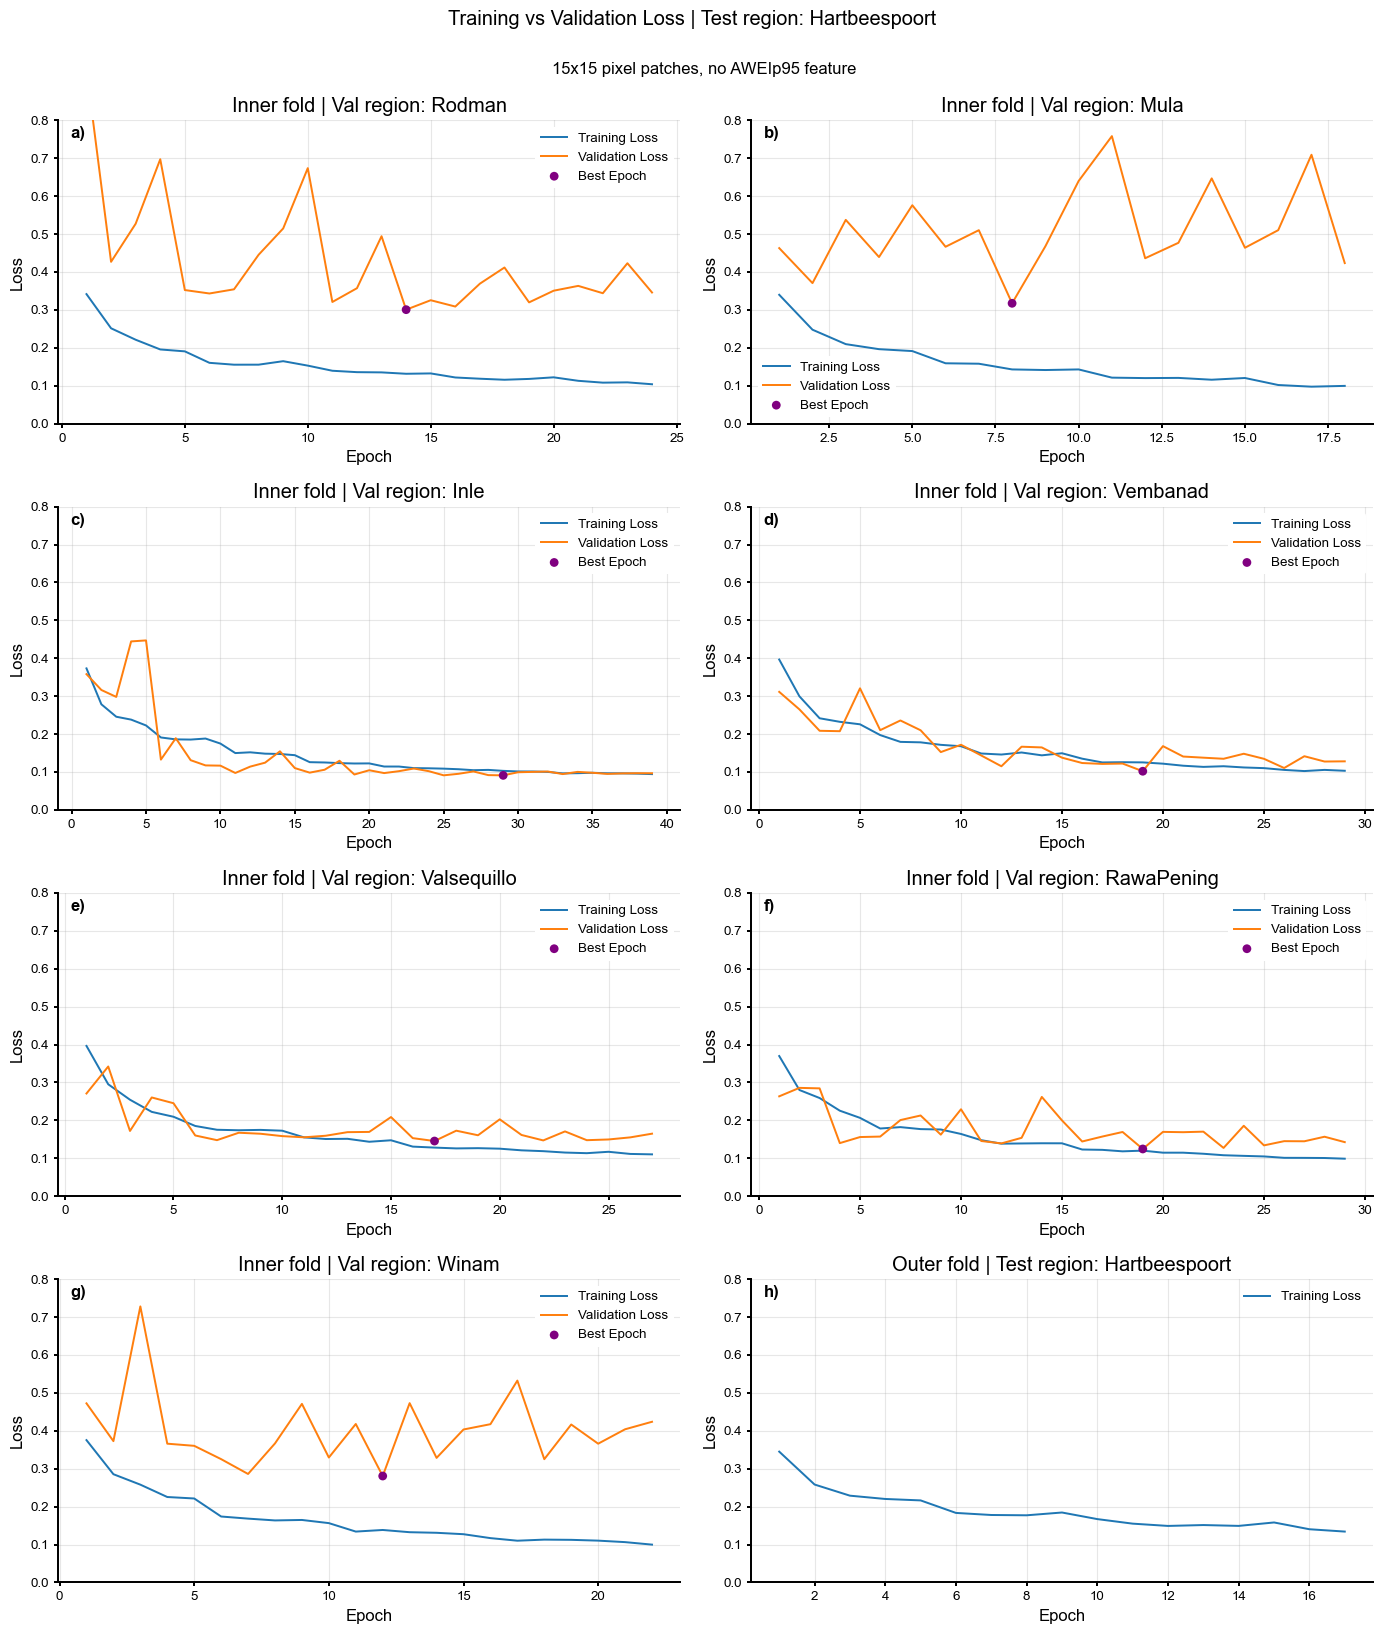

array([<Axes: title={'center': 'Inner fold | Val region: Rodman'}, xlabel='Epoch', ylabel='Loss'>,
       <Axes: title={'center': 'Inner fold | Val region: Mula'}, xlabel='Epoch', ylabel='Loss'>,
       <Axes: title={'center': 'Inner fold | Val region: Inle'}, xlabel='Epoch', ylabel='Loss'>,
       <Axes: title={'center': 'Inner fold | Val region: Vembanad'}, xlabel='Epoch', ylabel='Loss'>,
       <Axes: title={'center': 'Inner fold | Val region: Valsequillo'}, xlabel='Epoch', ylabel='Loss'>,
       <Axes: title={'center': 'Inner fold | Val region: RawaPening'}, xlabel='Epoch', ylabel='Loss'>,
       <Axes: title={'center': 'Inner fold | Val region: Winam'}, xlabel='Epoch', ylabel='Loss'>,
       <Axes: title={'center': 'Outer fold | Test region: Hartbeespoort'}, xlabel='Epoch', ylabel='Loss'>],
      dtype=object)

In [331]:
plot_loss_curves(history, "Hartbeespoort", facet = True)


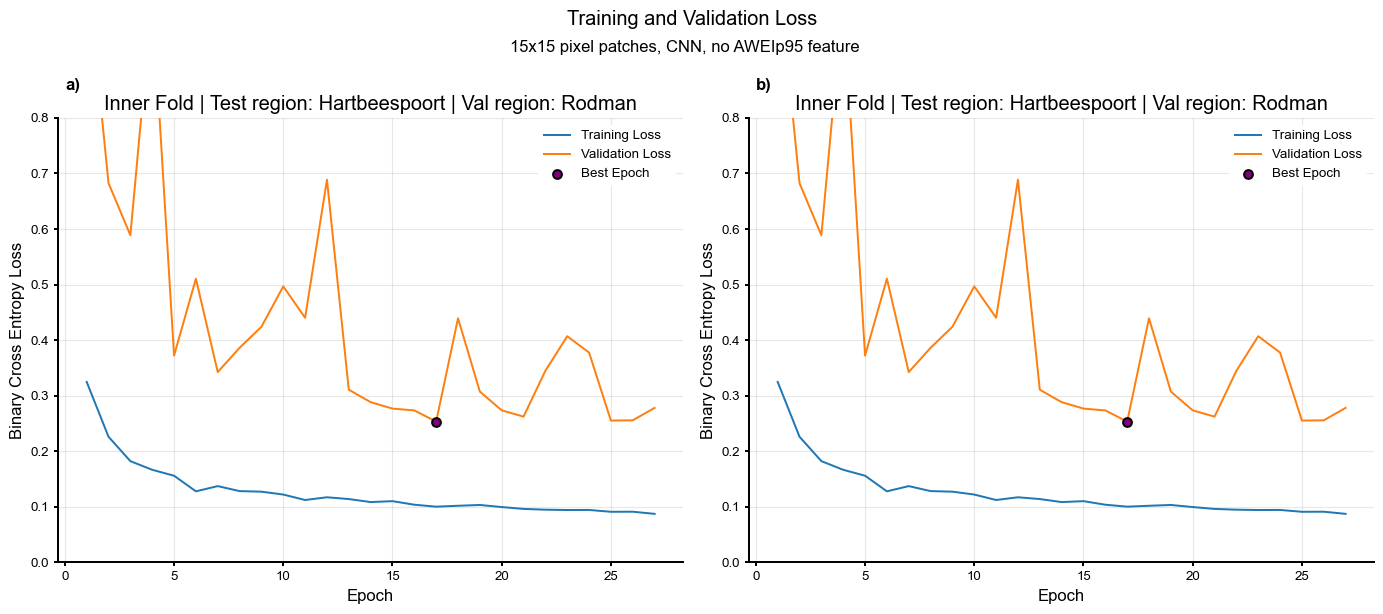

In [327]:
# Side by side loss curve comparison

df = history_cnn_15px_NO_AWEI
left_test_region, left_val_region  = ("Hartbeespoort", "Rodman")
right_test_region, right_val_region = ("Hartbeespoort", "Rodman")
fold = "inner"
model = "CNN"

patch_size = df["patch_size"][0]
AWEI = df["AWEIp95"][0]

if AWEIp95:
    if model:
        subtitle_text = f"{patch_size}x{patch_size} pixel patches, {model}, with AWEIp95 feature"
    else:
        subtitle_text = f"{patch_size}x{patch_size} pixel patches, with AWEIp95 feature"
else:
    if model:
        subtitle_text = f"{patch_size}x{patch_size} pixel patches, {model}, no AWEIp95 feature"
    else:
        subtitle_text = f"{patch_size}x{patch_size} pixel patches, no AWEIp95 feature"

# Get model info for subtitle 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_loss_curves(df, test_region = left_test_region, val_region = left_val_region,fold= fold, ax=axes[0])
plot_loss_curves(df, test_region = right_test_region, val_region= right_val_region, fold= fold, ax=axes[1])
fig.suptitle(f"Training and Validation Loss", y = 1.02)

axes[0].text(0.02, 0.85, "a)", fontweight = "bold")
axes[1].text(0.02, 0.85, "b)", fontweight = "bold")

fig.text(0.37, 0.95, subtitle_text)
plt.tight_layout()
plt.show()